In [1]:
	
import pickle

# Replace 'your_file.pkl' with the path to your .pkl file
file_path = '/home/rg625@ad.eng.cam.ac.uk/mnt/ScoreVAE/results/ffhq/unconditional/config.pkl'

# Open and load the .pkl file
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Print or process the loaded data
print(data)

data:
  base_dir: /home/gb511/rds_work/datasets/
  centered: false
  class_cond: false
  create_dataset: false
  datamodule: guided_diffusion_dataset
  dataset: ffhq
  effective_image_size: 128
  image_size: 128
  latent_dim: 512
  num_channels: 3
  percentage_use: 100
  random_crop: false
  random_flip: false
  return_labels: false
  shape:
  - 3
  - 128
  - 128
  split:
  - 0.9
  - 0.05
  - 0.05
  use_data_mean: false
eval:
  batch_size: 64
  begin_ckpt: 50
  bpd_dataset: test
  callback: null
  enable_bpd: false
  enable_loss: true
  enable_sampling: true
  end_ckpt: 96
  num_samples: 50000
  workers: 4
logging:
  envery_timedelta: !!python/object/apply:datetime.timedelta
  - 0
  - 60
  - 0
  every_n_epochs: 1000
  log_name: DiffDecoders_continuous_prior
  log_path: /home/gb511/rds_work/projects/scoreVAE/experiments/gd_ffhq
  top_k: 5
model:
  attention_resolutions: !!python/tuple
  - 16
  attn_checkpoint: false
  channel_mult: !!python/tuple
  - 1
  - 1
  - 2
  - 3
  - 4
  checkpoi

In [1]:
!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("greatgamedota/ffhq-face-data-set")

print("Path to dataset files:", path)

100%|██████████| 1.97G/1.97G [00:54<00:00, 38.6MB/s]

Extracting files...


Path to dataset files: /home/rg625/.cache/kagglehub/datasets/greatgamedota/ffhq-face-data-set/versions/2


In [2]:
	
import pickle

# Replace 'your_file.pkl' with the path to your .pkl file
file_path = '/home/rg625@ad.eng.cam.ac.uk/mnt/ScoreVAE/results/ffhq/scoreVAE_noise/config.pkl'

# Open and load the .pkl file
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Print or process the loaded data
print(data)

data:
  base_dir: /home/gb511/rds_work/datasets/
  centered: true
  class_cond: false
  create_dataset: false
  datamodule: guided_diffusion_dataset
  dataset: ffhq
  effective_image_size: 128
  image_size: 128
  latent_dim: 512
  num_channels: 3
  percentage_use: 100
  random_crop: false
  random_flip: false
  return_labels: false
  shape:
  - 3
  - 128
  - 128
  split:
  - 0.9
  - 0.05
  - 0.05
  use_data_mean: false
eval:
  batch_size: 64
  begin_ckpt: 50
  bpd_dataset: test
  callback: null
  enable_bpd: false
  enable_loss: true
  enable_sampling: true
  end_ckpt: 96
  num_samples: 50000
  workers: 4
logging:
  envery_timedelta: !!python/object/apply:datetime.timedelta
  - 0
  - 60
  - 0
  every_n_epochs: 1000
  log_name: BeatGANsEncoder_flatten_linear
  log_path: /home/gb511/rds_work/projects/scoreVAE/experiments/gd_ffhq
  top_k: 3
model:
  attn_checkpoint: false
  checkpoint_path: null
  conv_resample: true
  dims: 2
  dropout: 0
  ema_rate: 0.999
  embed_channels: 512
  enc_att

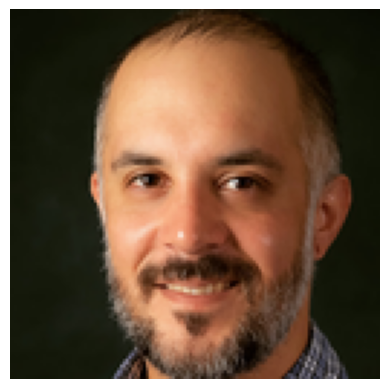

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/home/rg625@ad.eng.cam.ac.uk/datasets/ffhq/69450.png")
plt.imshow(img)
plt.axis('off')
plt.show()

In [9]:
import json
from dash import Dash, dcc, html, Output, Input
import plotly.graph_objs as go

# Load data
with open('ablation/grid_results.json', 'r') as f:
    data = json.load(f)

# Parse keys
lookup = {}
a_vals, b_vals, c_vals = set(), set(), set()

for key, val in data.items():
    a_b, c = key.split('-')
    a, b = map(float, a_b.split(','))
    c = float(c)
    lookup[(a, b, c)] = val
    a_vals.add(a)
    b_vals.add(b)
    c_vals.add(c)

a_vals = sorted(a_vals)
b_vals = sorted(b_vals)
c_vals = sorted(c_vals)

# Dash app
app = Dash(__name__)
app.title = "Ablation Grid Explorer"

app.layout = html.Div(style={"display": "flex", "padding": "40px"}, children=[
    html.Div(style={"width": "30%", "paddingRight": "20px"}, children=[
        html.H4("Select Parameters:"),
        html.Label("Weight (a):"),
        dcc.Slider(min=min(a_vals), max=max(a_vals), step=round((max(a_vals) - min(a_vals))/len(a_vals), 4),
                   marks={v: str(round(v, 2)) for v in a_vals}, value=a_vals[0], id="slider-a"),
        html.Br(),
        html.Label("Lower Limit (b):"),
        dcc.Slider(min=min(b_vals), max=max(b_vals), step=round((max(b_vals) - min(b_vals))/len(b_vals), 4),
                   marks={v: str(round(v, 2)) for v in b_vals}, value=b_vals[0], id="slider-b"),
        html.Br(),
        html.Label("Upper Limit (c):"),
        dcc.Slider(min=min(c_vals), max=max(c_vals), step=round((max(c_vals) - min(c_vals))/len(c_vals), 4),
                   marks={v: str(round(v, 2)) for v in c_vals}, value=c_vals[0], id="slider-c"),
    ]),

    html.Div(style={"width": "70%"}, children=[
        dcc.Graph(id="output-plot"),
        html.Div(id="output-text", style={"fontSize": "18px", "paddingTop": "10px"})
    ])
])

@app.callback(
    Output("output-plot", "figure"),
    Output("output-text", "children"),
    Input("slider-a", "value"),
    Input("slider-b", "value"),
    Input("slider-c", "value"),
)
def update_output(a, b, c):
    val = lookup.get((a, b, c))
    if val is not None:
        fig = go.Figure()
        fig.add_trace(go.Bar(
            x=["Loss"],
            y=[val],
            text=[f"{val:.4f}"],
            textposition="auto",
            marker_color="royalblue"
        ))
        fig.update_layout(title=f"Loss for a={a}, b={b}, c={c}",
                          yaxis_title="Loss",
                          height=400)
        return fig, f"Loss for configuration (a={a}, b={b}, c={c}): {val:.4f}"
    else:
        fig = go.Figure()
        fig.update_layout(title="No data available for this combination.",
                          height=400)
        return fig, "⚠️ No data for this combination."
